# Stage 2D — Bi-LSTM Training
### ISL Real-Time Sign Language Translator

**What this notebook does:**
1. Mount Google Drive and load extracted landmarks
2. Inspect and visualize the dataset
3. Build a Bi-LSTM sequence classifier
4. Train with early stopping
5. Plot loss and accuracy curves
6. Evaluate on the test set
7. Save the trained model

**Expected input files in Google Drive:**
- `landmarks_index.csv`
- `label_map.csv`
- `extracted_landmarks.zip` (or `extracted_landmarks/` folder)

**Runtime:** Set to T4 GPU → Runtime → Change runtime type → T4 GPU

In [15]:
from google.colab import drive
drive.mount('/content/drive')
import os

drive_dir = "/content/drive/MyDrive"
landmarks_zip = os.path.join(drive_dir, 'extracted_landmarks.zip')
index_csv = os.path.join(drive_dir, 'landmarks_index.csv')
label_map_csv = os.path.join(drive_dir, 'label_map.csv')
extract_dir = '/content/extracted_landmarks'
model_save_dir = '/content/drive/MyDrive'

os.makedirs(model_save_dir, exist_ok=True)

if not os.path.exists(extract_dir):
  print("Unzipping extracted_landmarks.zip...")
  os.system(f"unzip -q {landmarks_zip} -d/content")
  print("Done")
else:
  print("extracted_landmarks/ already exists, skipping unzip.")
print("Drive mounted and paths configured.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
extracted_landmarks/ already exists, skipping unzip.
Drive mounted and paths configured.


## Cell 2 — Imports and GPU Check

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
  print(f"GPU: {torch.cuda.get_device_name(0)}")
  print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

torch.manual_seed(42)
np.random.seed(42)

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## Cell 3 — Load and Inspect Dataset

Total sequences: 943
Classes: 50

split breakdown: 
split
train    675
test     191
val       77
Name: count, dtype: int64

Sequence length min: 36 max: 154


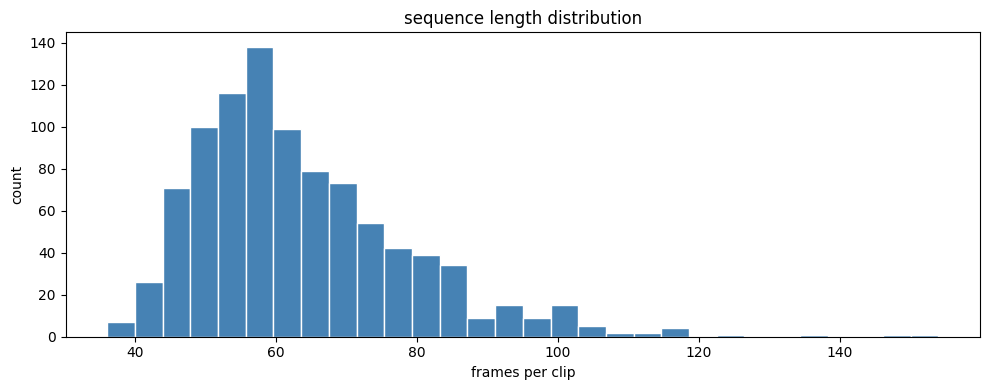

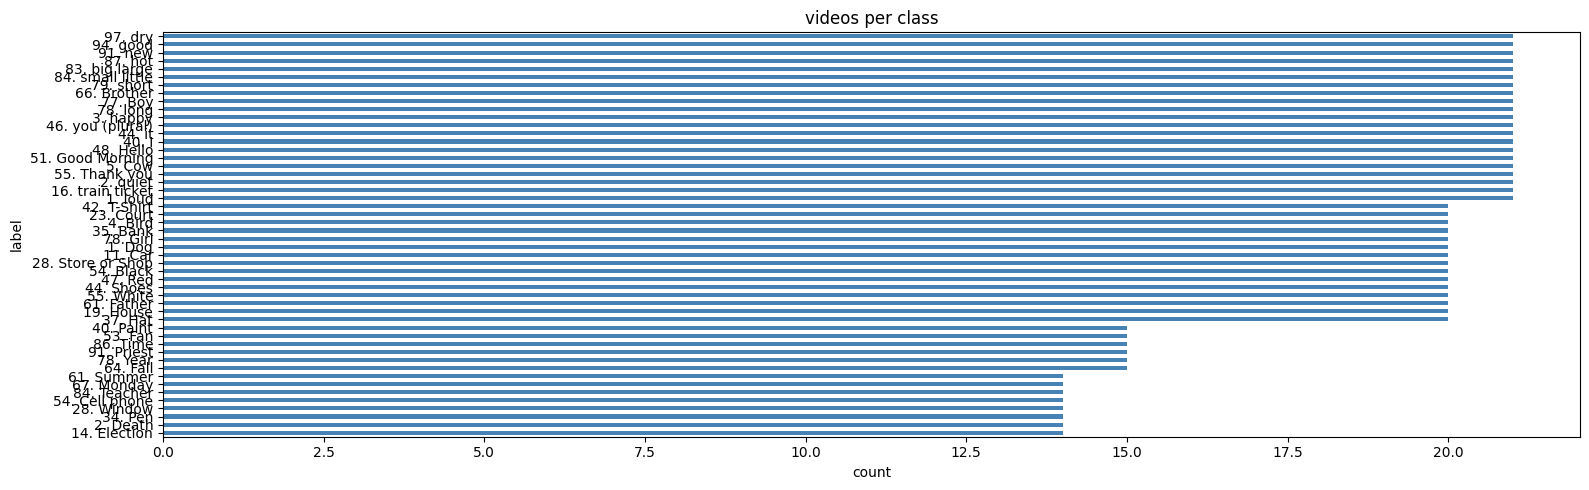

In [17]:
index_df = pd.read_csv(index_csv)
label_map = pd.read_csv(label_map_csv)

index_df['npy_path'] = index_df['video_path'].apply(
    lambda p: str(Path(extract_dir) / Path(p).with_suffix('.npy'))
)
print(f'Total sequences: {len(index_df)}')
print(f"Classes: {index_df['class_index'].nunique()}")
print()
print("split breakdown: ")
print(index_df['split'].value_counts())
print()

lengths = []
for path in index_df['npy_path']:
  try:
    seq = np.load(path)
    lengths.append(seq.shape[0])
  except:
    lengths.append(0)

index_df['seq_length'] = lengths
print(f"Sequence length min: {min(lengths)} max: {max(lengths)}")

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=30, color='steelblue', edgecolor='white')
plt.title('sequence length distribution')
plt.xlabel('frames per clip')
plt.ylabel('count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 5))
class_counts = index_df.groupby('label').size().sort_values()
class_counts.plot(kind='barh', color='steelblue')
plt.title('videos per class')
plt.xlabel('count')
plt.tight_layout()
plt.show()

## Cell 4 — Dataset and DataLoader

In [26]:
class ISLDataset(Dataset):
  def __init__(self, df):
    self.df = df.reset_index(drop=True)

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    sequence = np.load(row['npy_path']).astype(np.float32)
    label = int(row['class_index'])
    length = sequence.shape[0]
    return torch.tensor(sequence), label, length

  def collate_fn(batch):
    sequences, labels, lengths = zip(*batch)
    padded = pad_sequence(sequences, batch_first=True, padding_value=0.0)
    labels = torch.tensor(labels, dtype=torch.long)
    lengths = torch.tensor(lengths, dtype=torch.long)
    return padded, labels, lengths

train_df = index_df[index_df['split'] == 'train']
val_df = index_df[index_df['split'] == 'val']
test_df = index_df[index_df['split'] == 'test']

print(f"Train: {len(train_df)} val: {len(val_df)} test: {len(test_df)}")

batch_size = 32

train_loader = DataLoader(ISLDataset(train_df), batch_size, shuffle=False, collate_fn=ISLDataset.collate_fn)
val_loader = DataLoader(ISLDataset(val_df), batch_size, shuffle=False, collate_fn=ISLDataset.collate_fn)
test_loader = DataLoader(ISLDataset(test_df), batch_size, shuffle=False, collate_fn=ISLDataset.collate_fn)

seqs, labels, lengths = next(iter(train_loader))
print(f"Batch shape: {seqs.shape} Labels shape: {labels.shape} Lengths: {lengths[:5]}")

Train: 675 val: 77 test: 191
Batch shape: torch.Size([32, 109, 1692]) Labels shape: torch.Size([32]) Lengths: tensor([56, 45, 70, 45, 61])
